# Analysing the results from Deepseek

After running te experiments for three times the results are analysed to check 
1. Consistency
2. Prompt Sensitivity 
3. How the ups and downs imapct the model predictions


To begin  the three dataframes are loaded and combined into a single csv file as these are saved in three different file 


In [1]:
import pandas as pd 
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

In [2]:
exp_1 = pd.read_csv("/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/sample_experiment/exp1_labeled.csv")
exp_1.head()

,label,comment,subreddit,score,ups,downs,parent_comment,exp1_label
0,0,Reactionary decisions rarely create tranquility.,investing,1,1,0,"In 2008, I always wondered why my sister lost ...",0.0
1,0,These will have to be replaced with software t...,Bitcoin,1,1,0,...what?,1.0
2,0,Or a money cow,investing,2,2,0,Nobody wants to be Dad.,0.0
3,0,"Google ""filetype:ppt"" and a keyword or two.",finance,1,1,0,Anybody have a ppt deck they could share?,0.0
4,0,"Well, more like 2ch lol.",Bitcoin,2,2,0,Lol and reddit I'm sure he's reading this stuf...,1.0


In [3]:
exp_2 = pd.read_csv("/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/sample_experiment/exp2_labeled.csv")
exp_2.head()

,label,comment,subreddit,score,ups,downs,parent_comment,exp2_label
0,0,Reactionary decisions rarely create tranquility.,investing,1,1,0,"In 2008, I always wondered why my sister lost ...",0
1,0,These will have to be replaced with software t...,Bitcoin,1,1,0,...what?,1
2,0,Or a money cow,investing,2,2,0,Nobody wants to be Dad.,0
3,0,"Google ""filetype:ppt"" and a keyword or two.",finance,1,1,0,Anybody have a ppt deck they could share?,0
4,0,"Well, more like 2ch lol.",Bitcoin,2,2,0,Lol and reddit I'm sure he's reading this stuf...,1


In [4]:
exp_3 = pd.read_csv("/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/sample_experiment/exp3_labeled.csv")
exp_3.head()

,label,comment,subreddit,score,ups,downs,parent_comment,exp3_label
0,0,Reactionary decisions rarely create tranquility.,investing,1,1,0,"In 2008, I always wondered why my sister lost ...",0
1,0,These will have to be replaced with software t...,Bitcoin,1,1,0,...what?,0
2,0,Or a money cow,investing,2,2,0,Nobody wants to be Dad.,1
3,0,"Google ""filetype:ppt"" and a keyword or two.",finance,1,1,0,Anybody have a ppt deck they could share?,0
4,0,"Well, more like 2ch lol.",Bitcoin,2,2,0,Lol and reddit I'm sure he's reading this stuf...,1


In [5]:
exp2_label = exp_2[["exp2_label"]]
exp3_label = exp_3[["exp3_label"]]

combined_data = pd.concat([exp_1,exp2_label, exp3_label],axis=1)
combined_data.head()

,label,comment,subreddit,score,ups,downs,parent_comment,exp1_label,exp2_label,exp3_label
0,0,Reactionary decisions rarely create tranquility.,investing,1,1,0,"In 2008, I always wondered why my sister lost ...",0.0,0,0
1,0,These will have to be replaced with software t...,Bitcoin,1,1,0,...what?,1.0,1,0
2,0,Or a money cow,investing,2,2,0,Nobody wants to be Dad.,0.0,0,1
3,0,"Google ""filetype:ppt"" and a keyword or two.",finance,1,1,0,Anybody have a ppt deck they could share?,0.0,0,0
4,0,"Well, more like 2ch lol.",Bitcoin,2,2,0,Lol and reddit I'm sure he's reading this stuf...,1.0,1,1


In [6]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   label           590 non-null    int64  
 1   comment         590 non-null    object 
 2   subreddit       590 non-null    object 
 3   score           590 non-null    int64  
 4   ups             590 non-null    int64  
 5   downs           590 non-null    int64  
 6   parent_comment  590 non-null    object 
 7   exp1_label      590 non-null    float64
 8   exp2_label      590 non-null    int64  
 9   exp3_label      590 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 46.2+ KB


#### When checking the types of entries in each column, the data type of the exp1_label column is float64. Convert the data type of exp1_label from float64 to int64 to streamline processing, ensure consistent formatting.

In [7]:
combined_data["exp1_label"] = combined_data["exp1_label"].astype("int64")
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           590 non-null    int64 
 1   comment         590 non-null    object
 2   subreddit       590 non-null    object
 3   score           590 non-null    int64 
 4   ups             590 non-null    int64 
 5   downs           590 non-null    int64 
 6   parent_comment  590 non-null    object
 7   exp1_label      590 non-null    int64 
 8   exp2_label      590 non-null    int64 
 9   exp3_label      590 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 46.2+ KB


In [8]:
combined_data.shape

(590, 10)

In [9]:
combined_data = combined_data.dropna(subset=["exp1_label", "exp2_label", "exp3_label"])
combined_data.shape

(590, 10)

# Evaluation Metrics 

#### To evaluate the performance of the DeepSeek Model, accuracy metrics are calculated. 

#### 1. Accuracy: Check the percentage of correctly labelled data 
#### 2. Precision: Among the predicted labels, it checks  how many are actually sarcastic and were predicted as sarcastic.
#### 3. Recall: Among all the sarcastic data in the dataset, how many were the model able to identify 
#### 4. F1 Score: Harmonic mean of precision and recall, showing the model performing well

In [10]:
# Assign the real label of the data comments to the variable real_label
real_label = combined_data["label"]       


# Create a for loop that will iterate through the three experiments and calculate the performance metrics for each experiment. 
# The metrics to be calculated are accuracy, precision, recall, and F1-score. The results will be printed for each experiment.

for i in [1, 2, 3]:
    deepseek_label = combined_data[f"exp{i}_label"]
    
    # Calculate accuracy, precision, recall, and F1-score for each experiment
    accuracy = accuracy_score(real_label, deepseek_label)
    precision = precision_score(real_label, deepseek_label, pos_label=1)
    recall = recall_score(real_label, deepseek_label, pos_label=1)
    f1 = f1_score(real_label, deepseek_label, pos_label=1)
    
    # Print the performance metrics for each experiment
    print(f"Experiment {i} Performance Metrics ")
    print("=================================")
    print("Accuracy : ", accuracy)
    print("Precision : ", precision)
    print("Recall : ", recall)
    print("F1-Score : ", f1)
    print("\n")


Experiment 1 Performance Metrics 
Accuracy :  0.5983050847457627
Precision :  0.5788043478260869
Recall :  0.7220338983050848
F1-Score :  0.6425339366515838


Experiment 2 Performance Metrics 
Accuracy :  0.5983050847457627
Precision :  0.5788043478260869
Recall :  0.7220338983050848
F1-Score :  0.6425339366515838


Experiment 3 Performance Metrics 
Accuracy :  0.6186440677966102
Precision :  0.6143790849673203
Recall :  0.6372881355932203
F1-Score :  0.6256239600665557




# Confusion Metrics

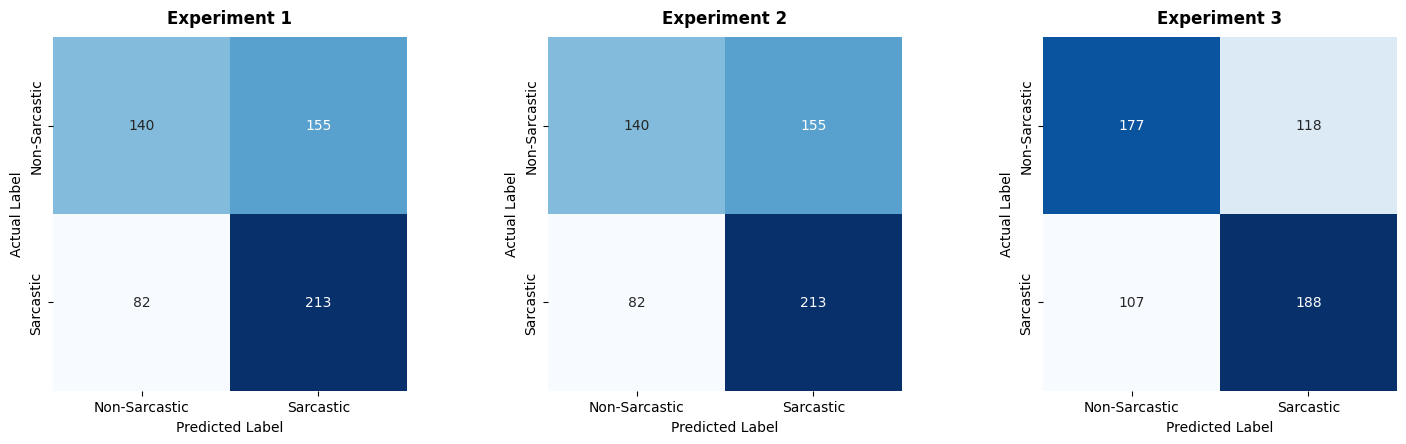

In [11]:
# Set up a map with three subplots side-by-side to visualize the confusion matrices for each experiment. Each subplot will have its own title and axis labels.
figure1, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))

# Assign the the class label of the data comments to the variable label_names 
label_names = ["Non-Sarcastic", "Sarcastic"]

# Loop through the experiments and plot its matrix
for i, ax in enumerate(axes, start=1):
    deepseek_label = combined_data[f"exp{i}_label"]
    
    # Calculate the confusion matrix
    cm = confusion_matrix(real_label, deepseek_label)
    
    # Plot the heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d",          
        cmap="Blues",     
        square=True, 
        xticklabels=label_names, 
        yticklabels=label_names, 
        cbar=False,       
        ax=ax
    )
    
    # Set the title, x- axis label and y-axis label for each subplot
    ax.set_title(f"Experiment {i}", fontsize=12, pad=10, weight='bold')
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("Actual Label", fontsize=10) 


plt.tight_layout()
image1 = "combined_confusion_matrices_all_labels.png"
plt.savefig(image1, dpi=300)



# Analysing the right predictions made by Experment 1, Experiment 2, Experiment 3

In [12]:
# Create new columns exp1_correct, exp2_correct, and exp3_correct in the combined_data DataFrame to indicate whether the predicted labels for each experiment match the actual labels.
combined_data['exp1_correct'] = combined_data['exp1_label'] == combined_data['label']
combined_data['exp2_correct'] = combined_data['exp2_label'] == combined_data['label']
combined_data['exp3_correct'] = combined_data['exp3_label'] == combined_data['label']

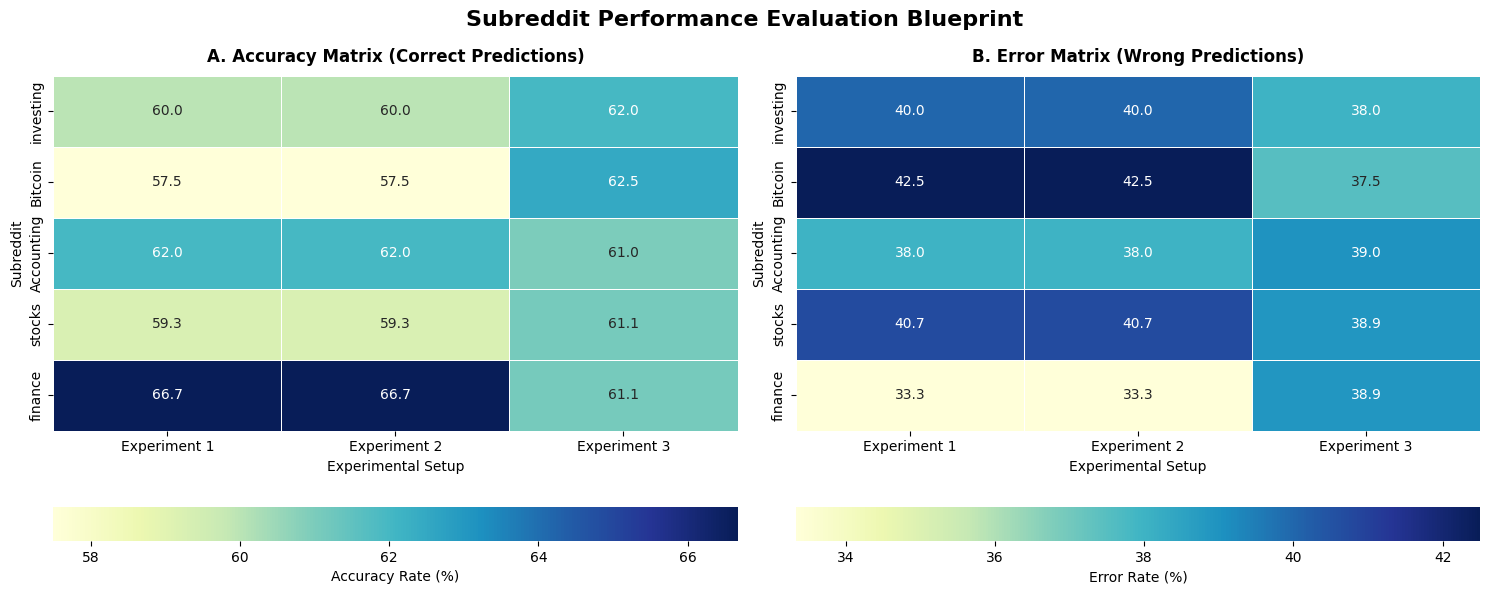

In [13]:
# Calculate the baseline Accuracy matrix per subreddit
df_accuracy = combined_data.groupby('subreddit')[['exp1_correct', 'exp2_correct', 'exp3_correct']].mean() * 100

# 3. Calculate the complementary Error matrix (100 - Accuracy)
df_error = 100 - df_accuracy

# Sort both dataframes identically by subreddit data volume (most active at top)
subreddit_order = combined_data['subreddit'].value_counts().index
df_accuracy = df_accuracy.reindex(subreddit_order)
df_error = df_error.reindex(subreddit_order)

# Rename columns for a clean visual presentation layout
experiment_headers = ['Experiment 1', 'Experiment 2', 'Experiment 3']
df_accuracy.columns = experiment_headers
df_error.columns = experiment_headers

# Create a single figure with 2 subplots side-by-side (1 row, 2 columns)
# Note: sharey=False is implicitly active here to ensure y-labels print on both axes
figure3, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Define the unified premium green-blue color theme variable
unified_theme = "YlGnBu"

# --- LEFT PLOT: Accuracy Heatmap (Using Unified 'YlGnBu' theme) ---
sns.heatmap(
    df_accuracy, 
    annot=True,          
    fmt=".1f",          
    cmap=unified_theme,   
    linewidths=.5,       
    cbar_kws={'label': 'Accuracy Rate (%)', 'orientation': 'horizontal', 'pad': 0.15},
    ax=axes[0]
)
axes[0].set_title("A. Accuracy Matrix (Correct Predictions)", fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel("Experimental Setup", fontsize=10)
axes[0].set_ylabel("Subreddit", fontsize=10)

# --- RIGHT PLOT: Error Heatmap (Using the exact same 'YlGnBu' theme) ---
sns.heatmap(
    df_error, 
    annot=True,          
    fmt=".1f",          
    cmap=unified_theme,   
    linewidths=.5,       
    cbar_kws={'label': 'Error Rate (%)', 'orientation': 'horizontal', 'pad': 0.15},
    ax=axes[1]
)
axes[1].set_title("B. Error Matrix (Wrong Predictions)", fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel("Experimental Setup", fontsize=10)
axes[1].set_ylabel("Subreddit", fontsize=10) # Enforced to display down the center margin gap

# 5. Add a master overarching title across the entire unified figure layout
plt.suptitle("Subreddit Performance Evaluation Blueprint", fontsize=16, weight='bold', y=0.98)

# Adjust spacing cleanly and save the single unified matrix plot
plt.tight_layout()
image3 = "unified_matrices_with_all_ylabels.png"
plt.savefig(image3, dpi=300)


###  In the above results the two subreddits that have maximum difference compared to the other subreddits are finance and bitcoin. Among the two finance have very less comments and bitcoin have most of the data. hence here after the study will be focusing on bitcoin.